In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

In [2]:
# Load the processed dataset
train_data = pd.read_csv('../dataset/processed/train_preprocessed_smote.csv')
test_data = pd.read_csv('../dataset/processed/test_preprocessed.csv')

X_train = train_data.drop('Default', axis=1)
y_train = train_data['Default']

X_test = test_data.drop('Default', axis=1)
y_test = test_data['Default']

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (56604, 22)
Test shape: (8000, 22)


In [3]:
# Separate input and output
X_train = train_data.drop('Default', axis=1)
y_train = train_data['Default']

X_test = test_data.drop('Default', axis=1)
y_test = test_data['Default']

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (56604, 22)
y_train shape: (56604,)
X_test shape: (8000, 22)
y_test shape: (8000,)


In [4]:
#Check feature names
feature_names = X_train.columns.tolist()
print(feature_names)

['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other']


In [22]:
#Create the Decision Tree model
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)


In [23]:
#Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")  


Decision Tree model trained successfully!


In [24]:
#Make predictions
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)
y_test_pred_proba = dt_model.predict_proba(X_test)[:, 1]


In [25]:
#Calculate training results
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, zero_division=0)
train_recall = recall_score(y_train, y_train_pred, zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, zero_division=0)

print("Training Accuracy:", train_accuracy)
print("Training Precision:", train_precision)
print("Training Recall:", train_recall)
print("Training F1-score:", train_f1)


Training Accuracy: 0.6954632181471274
Training Precision: 0.7146682188591386
Training Recall: 0.6507313970744117
Training F1-score: 0.681202840656902


In [26]:
#Calculate test results
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1-score:", test_f1)
print("Test ROC-AUC:", test_roc_auc)


Test Accuracy: 0.69825
Test Precision: 0.17867932671558048
Test Recall: 0.44756756756756755
Test F1-score: 0.2553979025293029
Test ROC-AUC: 0.6560357558972401


In [27]:

#Print classification report
print(classification_report(y_test, y_test_pred, target_names=['No Default', 'Default']))
print("Accuracy:", accuracy_score(y_test, y_test_pred))


              precision    recall  f1-score   support

  No Default       0.91      0.73      0.81      7075
     Default       0.18      0.45      0.26       925

    accuracy                           0.70      8000
   macro avg       0.54      0.59      0.53      8000
weighted avg       0.83      0.70      0.75      8000

Accuracy: 0.69825


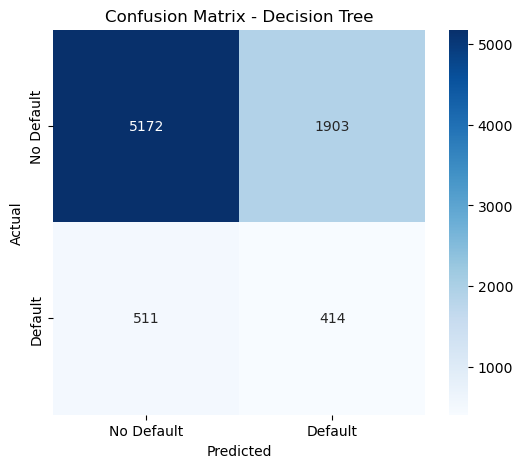

In [28]:
#Create confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


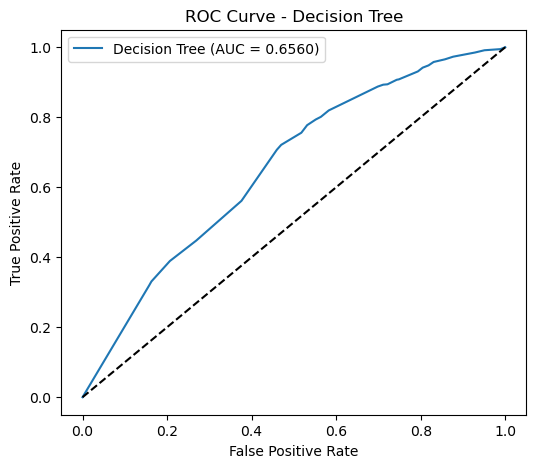

In [29]:
#Create ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {test_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - Decision Tree')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()
